In [1]:
import os
from pathlib import Path
from tempfile import TemporaryDirectory

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from disvoice import Articulation, Glottal, Phonation, Prosody, RepLearning

from src.waveform.utils import load_waveform, trim_waveform, save_waveform

################################################################################
### WARNING, path does not exist: KALDI_ROOT=/mnt/matylda5/iveselyk/Tools/kaldi-trunk
###          (please add 'export KALDI_ROOT=<your_path>' in your $HOME/.profile)
###          (or run as: KALDI_ROOT=<your_path> python <your_script>.py)
################################################################################



In [2]:
from inspect import signature

In [37]:
import time
from functools import wraps


def execution_time(func):
    @wraps(func)
    def wrapper(*args, log_execution_time=True, **kwargs):
        if log_execution_time:
            start_time = time.time()
        result = func(*args, **kwargs)
        if log_execution_time:
            end_time = time.time()
            execution_time = end_time - start_time
            print(f"Execution time of {func.__name__}: {execution_time:.6f} seconds")
        return result
    return wrapper


@execution_time
def disvoice_features(waveform, sample_rate, features_extractor_cls):
    with TemporaryDirectory() as temp_dir:
        # save temporary waveform file
        sample_path = Path(temp_dir) / 'sample.wav'
        save_waveform(waveform=waveform, sample_rate=sample_rate, save_path=sample_path)

        # initialize features extractor
        features_extractor = features_extractor_cls(
            **{
                k: v 
                for k, v in {'temp_dir': temp_dir, 'model': 'CAE'}.items()
                if k in signature(features_extractor_cls).parameters
            }
        )

        # extract features
        features = features_extractor.extract_features_file(
            sample_path.as_posix(), 
            static=True, 
            plots=False, 
            fmt="dataframe"
        )

    return features.iloc[0].to_dict()

In [44]:
waveform, sr = load_waveform(Path(os.environ['PROJECT_DIR']) / 'data/OSR_us_000_0030_8k.wav')
waveform = trim_waveform(waveform=waveform, sample_rate=sr, start_time=10, end_time=11)

In [46]:
features = disvoice_features(waveform=waveform, sample_rate=sr, features_extractor_cls=Articulation, log_execution_time=True)
features |= disvoice_features(waveform=waveform, sample_rate=sr, features_extractor_cls=Glottal, log_execution_time=True)
features |= disvoice_features(waveform=waveform, sample_rate=sr, features_extractor_cls=Phonation, log_execution_time=True)
features |= disvoice_features(waveform=waveform, sample_rate=sr, features_extractor_cls=Prosody, log_execution_time=True)
features |= disvoice_features(waveform=waveform, sample_rate=sr, features_extractor_cls=RepLearning, log_execution_time=True)

/usr/local/lib/python3.10/site-packages/disvoice/utils.py:50: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk.append(st.skew(k))
/usr/local/lib/python3.10/site-packages/disvoice/utils.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ku.append(st.kurtosis(k))


Execution time of disvoice_features: 0.113213 seconds
Execution time of extract_glottal_signal: 2.015882 seconds
Execution time of disvoice_features: 3.568819 seconds
Execution time of disvoice_features: 0.014620 seconds
Execution time of disvoice_features: 0.013975 seconds


/usr/local/lib/python3.10/site-packages/disvoice/replearning/AEspeech.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.AE.load_state_dict(torch.load(PATH+"/"+str(un

Execution time of disvoice_features: 0.374577 seconds


In [55]:
disvoice_features(waveform=waveform, sample_rate=sr, features_extractor_cls=Glottal, log_execution_time=True)
None

0.0020575523376464844
Execution time of se_vq_varf0: 1.902054 seconds
Execution time of extract_glottal_signal: 2.025039 seconds
Execution time of disvoice_features: 3.590574 seconds


In [9]:
# def unwrap_dict(dictionary: dict):
#     result = {f"{k}_{i}": val for k, v in dictionary.items() if isinstance(v, tuple) for i, val in enumerate(v)}
#     result.update({k: v for k, v in dictionary.items() if not isinstance(v, tuple)})
#     return result

In [11]:
df = pd.read_csv(PREPROCESSED_DATA_PATH / 'data.csv')
split_df = pd.read_csv(PREPROCESSED_DATA_PATH / 'split.csv').set_index('participant_id')
df['split'] = df['participant_id'].apply(lambda i: split_df.loc[i]['split'])

In [12]:
train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

In [13]:
y_train = train_df['phq_binary'].to_numpy().astype(int)
y_test = test_df['phq_binary'].to_numpy().astype(int)

In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

def calc(group):
    source = group.iloc[0]['source']
    waveform, sr = load_waveform(source)
    return group.progress_apply(
        lambda row: pd.Series(
            unwrap_dict(
                waveform_all_features(
                    waveform=trim_waveform(
                        waveform=waveform, 
                        sample_rate=sr, 
                        start_time=row['start_time'],
                        end_time=row['end_time']
                    ), 
                    sr=sr
                )
            )
        ), 
        axis=1
    )
    
X_train = train_df.groupby('participant_id').progress_apply(lambda group: calc(group), include_groups=False).reset_index(drop=True)

  0%|          | 0/197 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

In [102]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

def get_pca(df):
    # Handle null values
    imputer = SimpleImputer(strategy='mean')
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    
    # Feature scaling
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df.columns)
    
    # Dimensionality reduction with PCA for a two-dimensional overview
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(df_scaled)
    df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    
    return df_pca

In [104]:
pca = get_pca(X_train)

<Axes: xlabel='PC1', ylabel='PC2'>

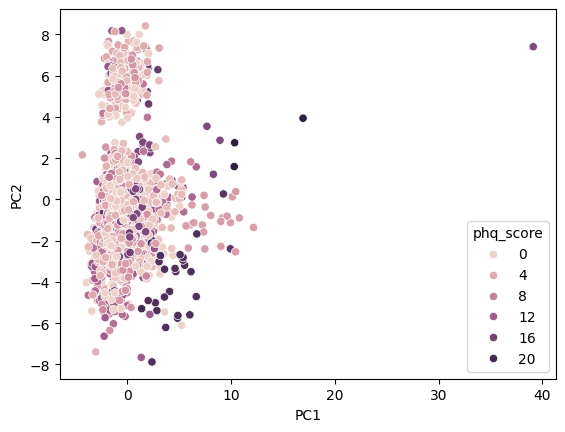

In [127]:
import seaborn as sns
sns.scatterplot(x=pca['PC1'], y=pca['PC2'], hue=train_df['phq_score'])

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

def is_significant(p_value):
    if p_value < 0.0001:
        return '****'
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*' 
    return ''

standardized_df = X_train.copy()
# Standardize the features
feature_cols = [col for col in X_train.columns if col != "phq_binary"]
standardized_df[feature_cols] = (X_train[feature_cols] - X_train[feature_cols].mean()) / X_train[feature_cols].std()
standardized_df['phq_binary'] = train_df['phq_binary'] 

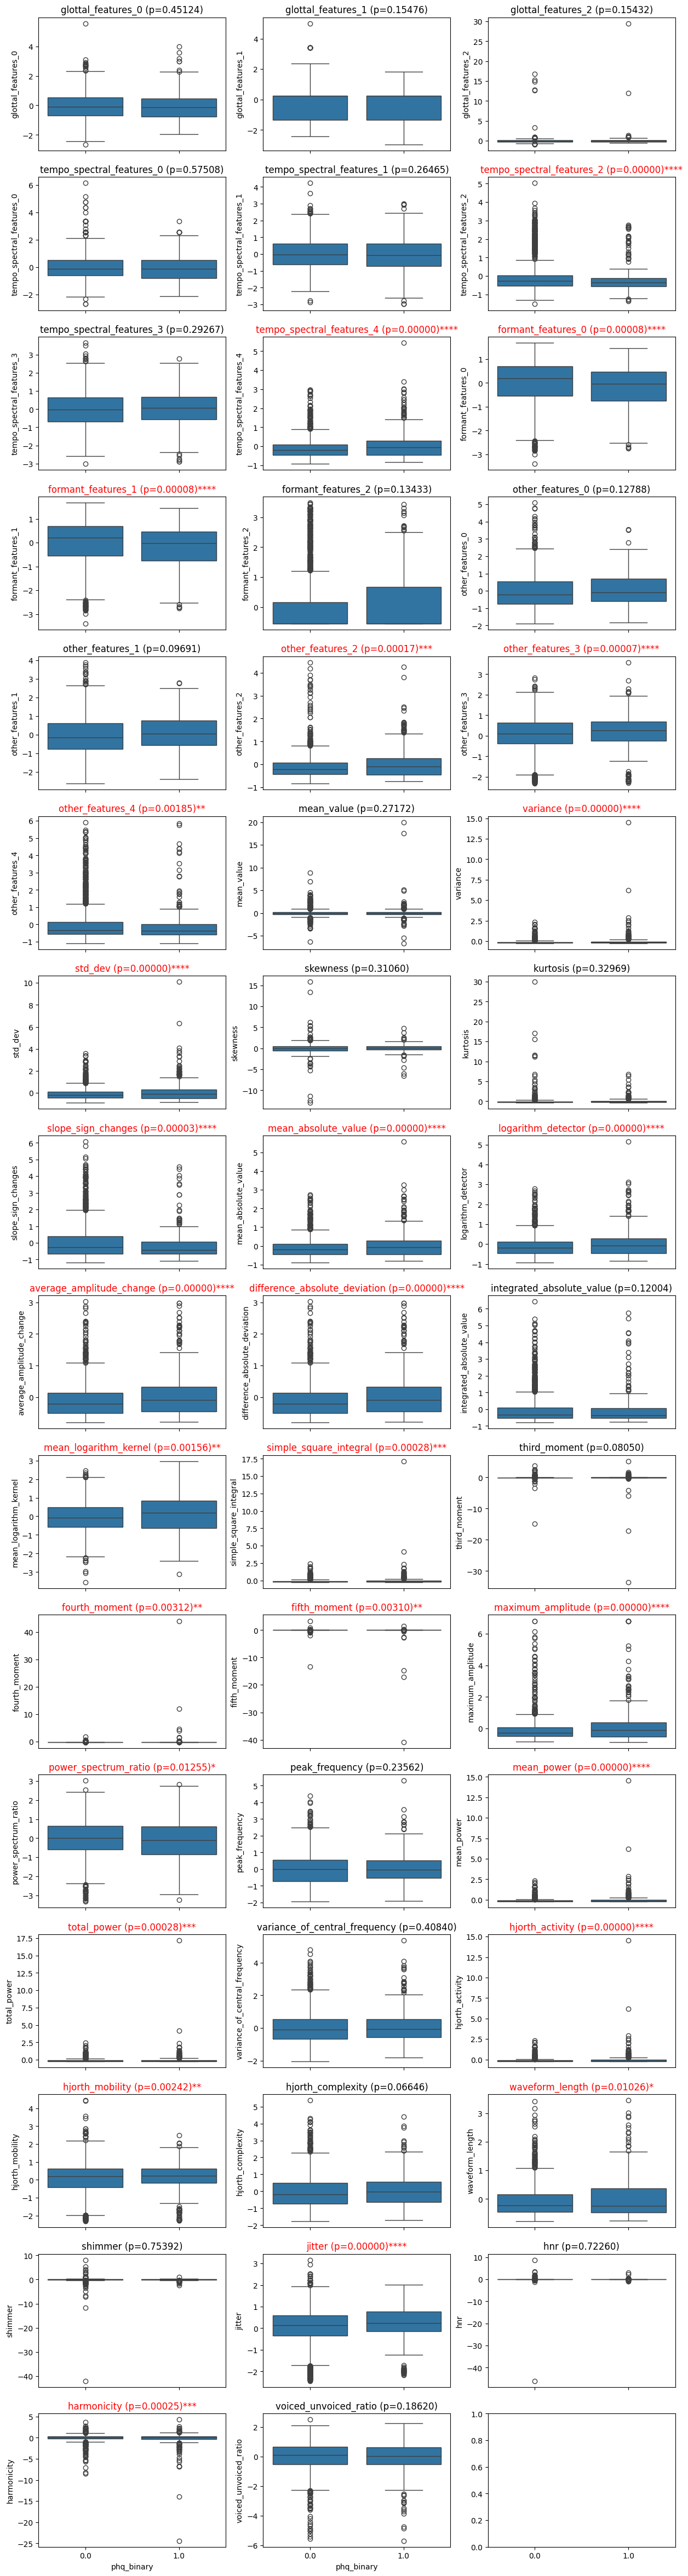

In [123]:
fig, ax = plt.subplots(16, 3, figsize=(15, 60), sharex=True)
ax = ax.flatten()

# Plot each feature
for i, feature in enumerate(feature_cols):
    sns.boxplot(x='phq_binary', y=feature, data=standardized_df, ax=ax[i])
    
    # Calculate T-test statistics between classes '0' and '1' for the target variable
    t_stat, p_val = ttest_ind(
        standardized_df[standardized_df['phq_binary'] == 0][feature], 
        standardized_df[standardized_df['phq_binary'] == 1][feature], 
        nan_policy='omit'
    )
    ax[i].set_title(f'{feature} (p={p_val:.5f}){is_significant(p_val)}', color=('red' if is_significant(p_val) else 'black'))

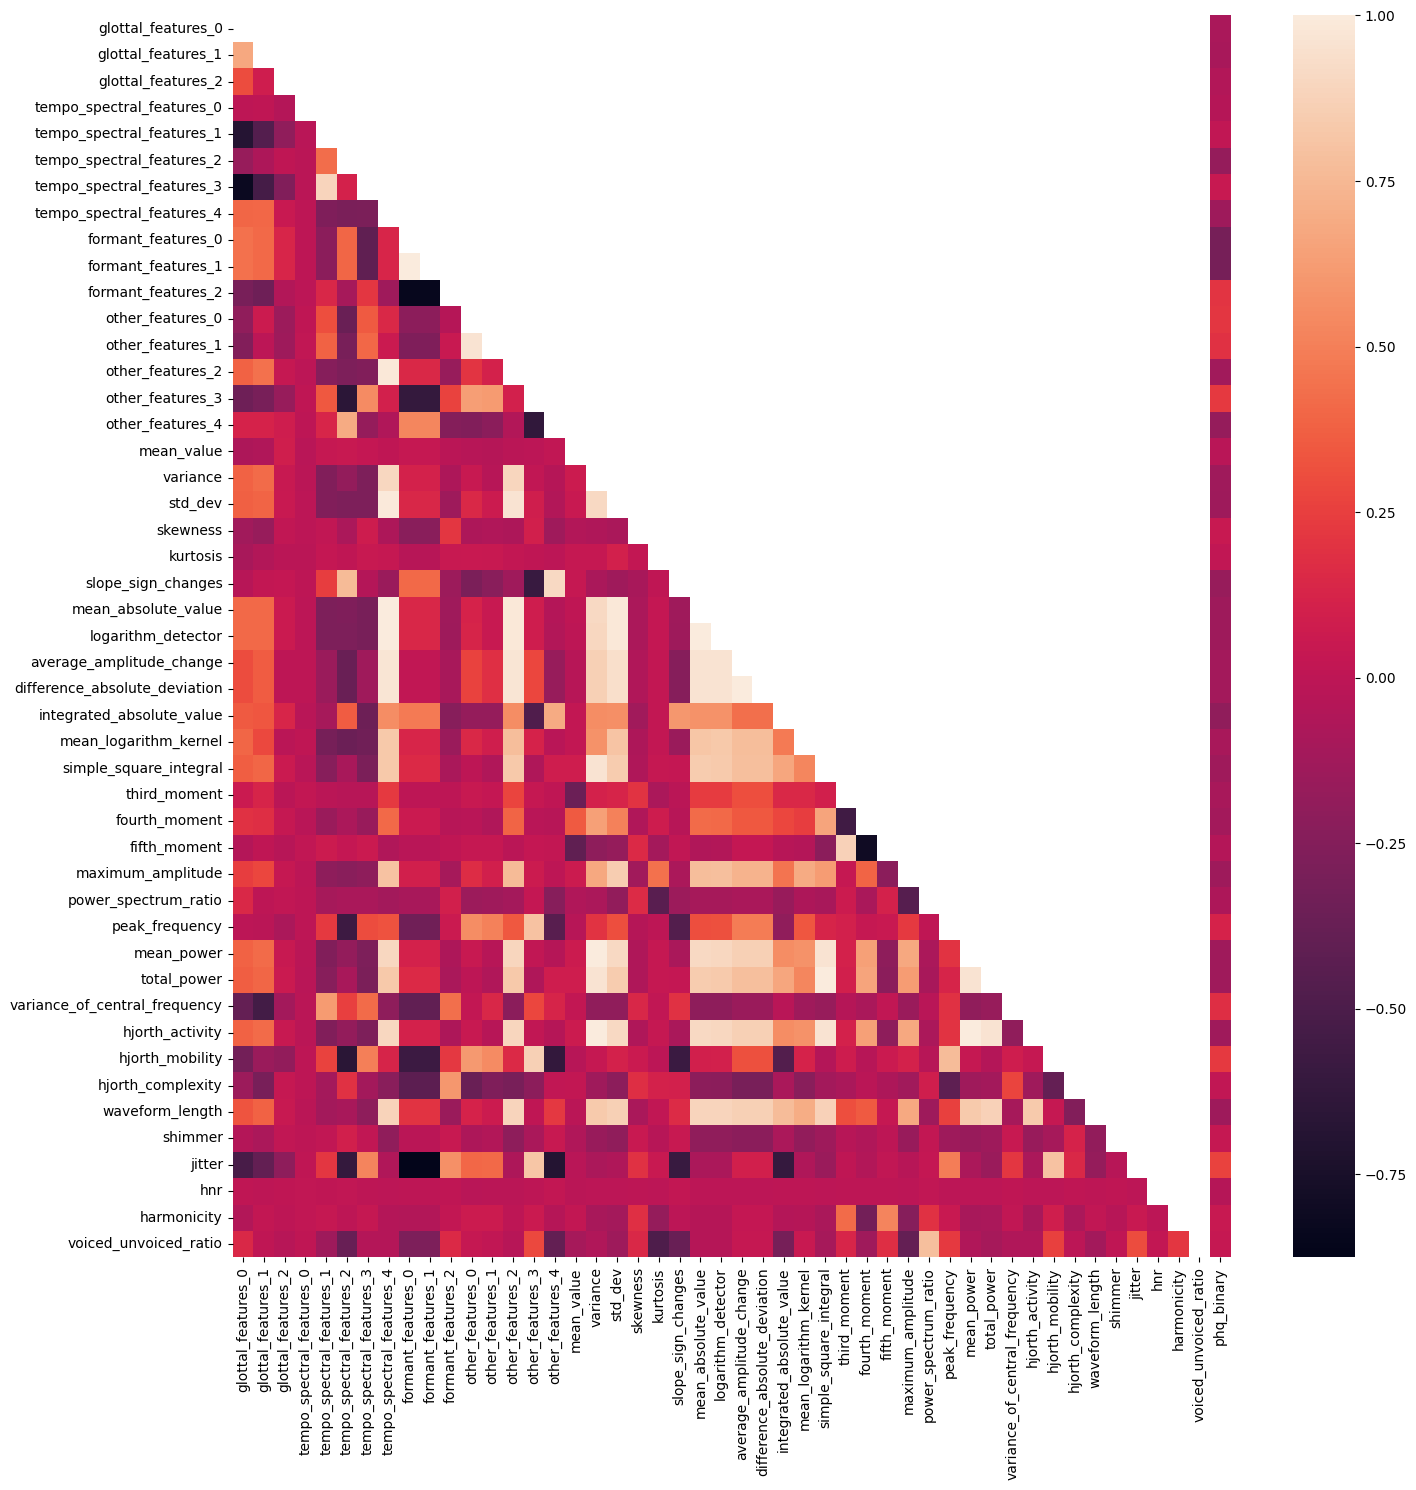

In [126]:
plt.figure(figsize=(15, 15))
corr_m = pd.concat([X_train, test_df['phq_binary']], axis=1).corr()
up_triang = np.triu(np.ones_like(corr_m)).astype(bool)
up_triang[:, -1] = 0
sns.heatmap(corr_m.iloc[:-1, :], mask=up_triang[:-1, :])
plt.tight_layout()